# Bài tập cá nhân môn Trí tuệ nhận tạo UTH 2026

## Mục tiêu bài tập

- __Mô tả:__ Sử dụng Linear Regression để dự đoán giá của các căn nhà dựa trên các yếu tố như diện tích, số phòng, vị trí, v.v.

- __Dữ liệu:__ Tập dữ liệu có thể được thu thập từ các trang web bất động sản, từ cơ quan quản lý bất động sản hoặc từ các dịch vụ môi giới bất động sản. Dữ liệu này bao gồm các thông tin về các căn nhà như diện tích, số phòng, vị trí, tiện ích xung quanh và giá bán thực tế.

- __Yêu cầu:__

    1. __Tiền xử lý dữ liệu:__ Đọc và khám phá dữ liệu. Xử lý dữ liệu thiếu, loại bỏ nhiễu, chuẩn hóa dữ liệu nếu cần. Chọn các đặc trưng phù hợp cho mô hình Linear Regression.

    2. __Chia tập dữ liệu:__ Chia dữ liệu thành tập huấn luyện và tập kiểm tra.

    3. __Xây dựng mô hình Linear Regression:__ Sử dụng tập dữ liệu huấn luyện để xây dựng một mô hình Linear Regression.

    4. __Đánh giá mô hình:__ Sử dụng tập dữ liệu kiểm tra để đánh giá hiệu suất của mô hình Linear Regression trong việc dự đoán giá nhà.

    5. __Tinh chỉnh mô hình:__ Thử nghiệm với các tham số khác nhau của Linear Regression như hệ số điều chỉnh (alpha), số lượng đặc trưng, v.v. để cải thiện hiệu suất của mô hình.

    6. __Dự đoán:__ Sử dụng mô hình tốt nhất để dự đoán giá nhà cho các căn nhà mới.

## Pipeline Tổng quát áp dụng cho bài tập
1. Data collection & Understanding
2. Data Preprocessing
3. Data Splitting (Train / Validation / Test)
4. Model Selection & Training
5. Evaluation & Tuning
6. Deployment & Monitoring (Predict cho dữ liệu mới.)

## Machine Learning Pipeline
```mermaid
flowchart LR

    A([Dataset]) --> B["1. Data Collection<br/>& Understanding"]

    B --> C["2. Data Preprocessing"]

    C --> D["3. Data Splitting<br/>(Train / Validation / Test)"]

    D --> E["4. Model Selection<br/>& Training"]

    E --> F["5. Evaluation<br/>& Hyperparameter Tuning"]

    F -->|Performance đạt yêu cầu| G["6. Deployment & Monitoring"]

    G --> H([Predict New Data])

    F -->|Performance chưa đạt| C
```

## Các thuật toán sử dụng trong bài tập


## Kết quả cuối cùng
- Hiểu về mô hình Linear Regression
- Hiểu về Data Pipeline & Machine Learning Pipeline
- Tìm ra tham số tốt nhất để dự đoán giá bất động sản
- Phân tích đặc điểm giữa các Feature với Target là __giá nhà (Prices)__
- Trực quan hóa Các outlier, missing Value của features
- Dựa vào Correlation Matrix để Chọn các Feature quan trọng với Target và thực hiện Feature Engineering.
- Cover doan nghiệp phân tích thị trường bất động sản và xây dựng hoạnh định chiến lược.


In [20]:
# Data Loader
import numpy as np
import pandas as pd

# Data Preprocessing

# EDA
from matplotlib import pyplot as plt
import seaborn as sns

# Feature Engineering

# Train Test Split

# Machine Learning
from sklearn.linear_model import LinearRegression

## 1. Data collection & Understanding

Bộ Dữ liệu được thu thập trên [Kaggle](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) Chứa một file csv:

- **melb_data.csv**

### Bối cảnh Bộ dữ liệu.
- Thị trường bất động sản tại Melbourne đang phát triển `bùng nổ`.

### Mục tiêu
- Sử dụng thuật toán học có giám sát __Linear Regression__ để dự đoán giá bất động sản trong bộ dữ liệu

### Mô tả các biến trong bộ dữ liệu

| Biến              | Ý nghĩa                                                                       |
| ----------------- | ----------------------------------------------------------------------------- |
| **Suburb**        | Tên khu vực/quận nơi căn nhà tọa lạc.                                         |
| **Address**       | Địa chỉ cụ thể của căn nhà.                                                   |
| **Rooms**         | Số lượng phòng của bất động sản.                                              |
| **Price**         | Giá bán của bất động sản (đơn vị: đô la Úc - AUD).                            |
| **Method**        | Phương thức bán bất động sản.                                                 |
| **Type**          | Loại hình bất động sản.                                                       |
| **SellerG**       | Đại lý hoặc công ty môi giới bất động sản.                                    |
| **Date**          | Ngày giao dịch (ngày bán).                                                    |
| **Distance**      | Khoảng cách từ bất động sản đến khu trung tâm thương mại (CBD).               |
| **Regionname**    | Khu vực tổng quát của bất động sản (West, North West, North, North East,...). |
| **Propertycount** | Số lượng bất động sản hiện có trong khu vực (Suburb).                         |
| **Postcode**      | Mã bưu điện của khu vực.                                                      |
| **Bedroom2**      | Số phòng ngủ được thu thập từ một nguồn dữ liệu khác.                         |
| **Bathroom**      | Số lượng phòng tắm.                                                           |
| **Car**           | Số chỗ đậu xe hoặc gara.                                                      |
| **Landsize**      | Diện tích khu đất.                                                            |
| **Lattitude**     | Vĩ độ của vị trí căn nhà.                                                     |
| **Longtitude**    | Kinh độ của vị trí căn nhà.                                                   |
| **BuildingArea**  | Diện tích xây dựng của ngôi nhà.                                              |
| **CouncilArea**   | Hội đồng địa phương (chính quyền quản lý khu vực) nơi bất động sản tọa lạc.   |
| **YearBuilt**     | Năm xây dựng căn nhà.                                                         |

### Data Loader

In [21]:
df = pd.read_csv(r"D:\Nam 2\Trí tuệ nhân tạo\E-Learning UTH AI-EX-2026\BT cá nhân\data\melb_data.csv")

samples, features = df.shape

print(f'Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: {samples} dòng (samples) và {features} cột (features)')

Sau khi Loader Data frame ta thu được dữ liệu raw ban đầu có: 13580 dòng (samples) và 21 cột (features)


- Từ Datasets ta có 13580 row (samples) và 21 columns (features)

In [22]:
print("5 mẫu đầu tiên trong Data Frame")
df.head()

5 mẫu đầu tiên trong Data Frame


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
print("Mô tả Data Frame")
df.describe()

Mô tả dữ liệu


,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


In [23]:
# Phân tích các giá trị null/na, duplicate và missing value

def report_Data_Quanlity(df):
    record = pd.DataFrame({
        'Column': df.columns,
        'Data Type': df.dtypes.values,
        'Non-Null Count': df.count().values,
        'Missing Count': df.isnull().sum().values,
        'Missing (%)': np.round(df.isnull().mean().values * 100, 2),
        'Duplicate Rows': df.duplicated().sum()
    })
    
    return record

report_data = report_Data_Quanlity(df)

display(report_data)

,Column,Data Type,Non-Null Count,Missing Count,Missing (%),Duplicate Rows
0,Suburb,str,13580,0,0.00,0
1,Address,str,13580,0,0.00,0
2,Rooms,int64,13580,0,0.00,0
3,Type,str,13580,0,0.00,0
4,Price,float64,13580,0,0.00,0
5,Method,str,13580,0,0.00,0
6,SellerG,str,13580,0,0.00,0
7,Date,str,13580,0,0.00,0
8,Distance,float64,13580,0,0.00,0
9,Postcode,float64,13580,0,0.00,0


### 1.1 Data Clearning
> Xử lý các dữ liệu bị lỗi thiếu và trùng lặp.

In [24]:
# Tạo một df để so sánh khi xử lý Data theo xóa hàng và theo min-max chose
df_drop_n = df

# Xử lý dữ liệu na
df_drop_n = df_drop_n.dropna()

# Xử lý dữ liệu trùng lặp
df_drop_n = df_drop_n.drop_duplicates()

print(f"Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: {df_drop_n.shape}")

Dữ liệu sau khi xử lý qua Drop Duplicate và Drop Na: (6196, 21)


> Sau khi xóa thẳng các dữ liệu bị missing (Na/Null) và xóa trùng lặp (duplicates) thì từ số mẫu ban đầu là 13580 xuống thẳng còn 6196 hơn 50% là một tổn thất về mặt dữ liệu rất lớn và dữ liệu này được lưu ở DataFrame: `df_drop_n`

In [32]:
# In các cột bị thiếu dữ liệu
missing_columns_report = report_data[report_data["Missing Count"] > 0]
print(missing_columns_report[["Column", "Data Type", "Missing Count", "Missing (%)"]])

          Column Data Type  Missing Count  Missing (%)
12           Car   float64             62         0.46
14  BuildingArea   float64           6450        47.50
15     YearBuilt   float64           5375        39.58
16   CouncilArea       str           1369        10.08


### Xử lí các cột thiếu dữ liệu Thủ công.
- Ta có 4 cột là [Car], [BuildingArea], [YearBuilt] và [CouncilArea]
    - Cột Car chỉ Missing có 0.46% $\rightarrow$ Drop luôn.
    - Cột BuildingArea Missing Tận 47.5% đây là features quan trọng cần có chiến lược xử lý cẩn trọng.
    - Cột YearBuilt Missing Tận 39.58% đây là features mà người mua nhà quan tâm nhất.
    - CouncilArea Missing mức 10.08% là một biến không quá quan trọng có thể tập chung vào cách xử lý cục bộ.

### 1.2 EDA
> Cái nhìn trực quan nhất về mối quan hệ giữa features và Target.

In [ ]:
# Phân tích quan hệ giữa 3 thuộc tính quan trọng Price, BuildingArea và Rooms

groupby_report = df.groupby('Rooms').agg(
    Count=('Price', 'count'),                         # Số lượng căn nhà theo từng loại phòng
    Mean_Price=('Price', 'mean'),                     # Giá trung bình
    Median_Price=('Price', 'median'),                 # Giá trung vị (tránh sai lệch do outlier)
    Mean_Area=('BuildingArea', 'mean'),               # Diện tích trung bình
    Median_Area=('BuildingArea', 'median'),           # Diện tích trung vị
    Price_per_m2=('Price', lambda x: (x / df.loc[x.index, 'BuildingArea']).mean()) # Giá TB trên mỗi m2
).reset_index()

groupby_report = groupby_report.round({
    'Mean_Price': 2, 
    'Median_Price': 2, 
    'Mean_Area': 2, 
    'Median_Area': 2, 
    'Price_per_m2': 2
})

# Sắp xếp theo số phòng tăng dần
groupby_report = groupby_report.sort_values(by='Rooms')

display(groupby_report)

,Rooms,Count,Mean_Price,Median_Price,Mean_Area,Median_Area,Price_per_m2
0,1,681,433824.45,385000.0,52.62,50.0,12039.79
1,2,3648,775081.19,690000.0,92.87,85.0,inf
2,3,5881,1076080.62,950000.0,139.15,129.0,inf
3,4,2688,1445281.74,1285000.0,208.97,190.0,inf
4,5,596,1870260.42,1660000.0,405.61,260.0,inf
5,6,67,1849365.67,1800000.0,278.51,284.0,17611.51
6,7,10,1920700.00,1496000.0,340.42,335.5,6118.80
7,8,8,1602750.00,1515000.0,256.00,152.5,5860.65
8,10,1,900000.00,900000.0,NaN,NaN,NaN


Phương trình đường hồi quy: Price = 3943.64 * BuildingArea + 510531.73


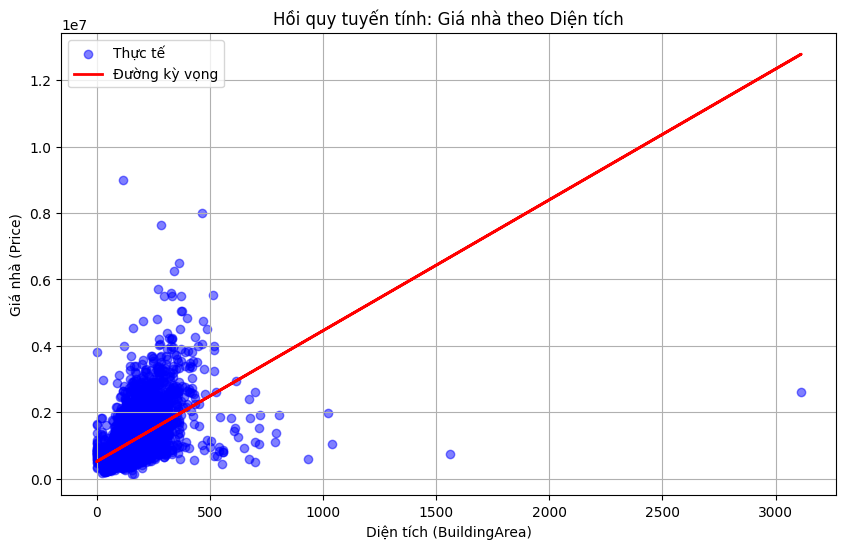

In [ ]:
# EDA đơn giản và trực quan giữa giá nhà và diện tích căn nhà

# Vì cột BuildingArea của df raw ban đầu có giá trị Nan nên để minh họa ta dùng df đã drop.

X = df_drop_n[["BuildingArea"]] # chuyển về mảng 2 chiều (100, 1) có 100 dòng và 1 cột rõ ràng theo quy định của sklearn
y = df_drop_n["Price"]          # mảng 1 chiều (100, ) -> chỉ có chiều dọc không có chiều ngang.

# Huấn luyện mô hình để tìm đường hồi quy tuyến tính giữa Giá nhà và diện tích.
model = LinearRegression()
model.fit(X, y)

slope = model.coef_[0]  # Hệ số góc Weight (w)
intercept = model.intercept_  # Hệ số chặn Bias (b)

print(f"Phương trình đường hồi quy: Price = {slope:.2f} * BuildingArea + {intercept:.2f}")

# Dự đoán giá nhà dựa trên diện tích
y_pred = model.predict(X)

# Vẽ biểu đồ trực quan
plt.figure(figsize=(10, 6))

# Vẽ các điểm dữ liệu thực tế (Scatter)
plt.scatter(df_drop_n["BuildingArea"], df_drop_n["Price"], color="blue", alpha=0.5, label="Thực tế")

# Vẽ đường thẳng dự đoán (Regression Line)
plt.plot(df_drop_n["BuildingArea"], y_pred, color="red", linewidth=2, label="Đường kỳ vọng")

plt.title("Hồi quy tuyến tính: Giá nhà theo Diện tích")
plt.xlabel("Diện tích (BuildingArea)")
plt.ylabel("Giá nhà (Price)")
plt.legend()
plt.grid(True)
plt.show()

> Qua hình ảnh hồi quy tuyến tính Giá nhà theo Diện tích. 
>
> Ta thấy có Outlier ở các điểm có 
>
> - Diện tích > 1000 mà giá qua thấp Price < 4, 000, 000. 
> - Điểm có diện tích nhỏ < 500 nhưng giá nhà quá cao Price > 8, 000, 000. 
> - Và hầu như Các căn nhà đều duy trì diện tích và giá thành ổn định (Diện tích < 1000 và Price < 6, 000, 000).
>

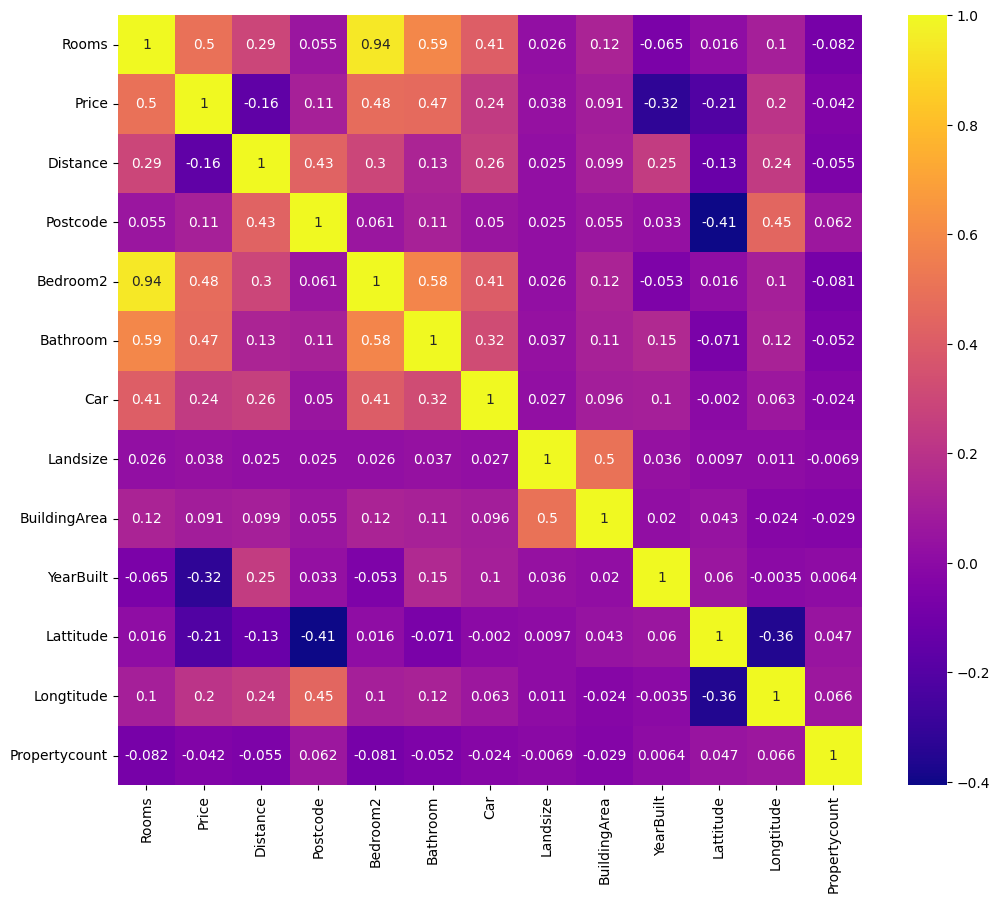

In [29]:
# Correlation Matrix để chọn các features tương quan mạnh với Target và giảm đa cộng tuyến.

plt.figure(figsize=(12, 10))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='plasma')
plt.show()

## 2. Data Preprocessing

## 3. Data Splitting

## 4. Model Selection & Training

## 5. Evaluation & Tuning

## 6. Deployment & Monitoring